<a href="https://colab.research.google.com/github/cysorianoc/Hugging_Face/blob/main/Notebook_11_visual_q_and_a.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lesson 12: Visual Question & Answering

We can ask questions to the model about an image. For that task we can use BLIP model.

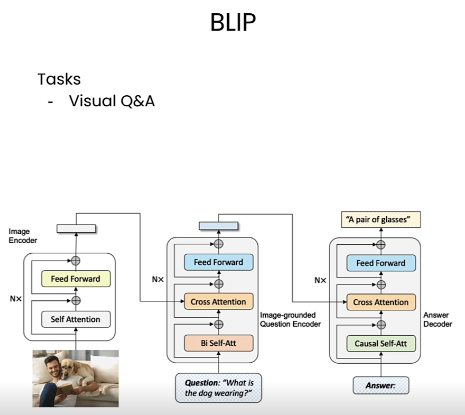


- In the classroom, the libraries are already installed for you.
- If you would like to run this code on your own machine, you can install the following:

```
    !pip install transformers
```

- Here is some code that suppresses warning messages.

In [1]:
from transformers.utils import logging
logging.set_verbosity_error()

import warnings
warnings.filterwarnings("ignore", message="Using the model-agnostic default `max_length`")

* Load the Model and the Processor.

In [2]:
from transformers import BlipForQuestionAnswering

In [3]:
model = BlipForQuestionAnswering.from_pretrained(
    "Salesforce/blip-vqa-base")

config.json:   0%|          | 0.00/4.56k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.54GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/788 [00:00<?, ?it/s]

Info about [Salesforce/blip-vqa-base](https://huggingface.co/Salesforce/blip-vqa-base)

In [4]:
from transformers import AutoProcessor

In [5]:
processor = AutoProcessor.from_pretrained(
    "Salesforce/blip-vqa-base")

preprocessor_config.json:   0%|          | 0.00/445 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

- Load the image.

In [6]:
from PIL import Image
from io import BytesIO
import requests

In [7]:
image_url="https://raw.githubusercontent.com/cysorianoc/Hugging_Face/main/beach.jpeg"
response = requests.get(image_url)
image = Image.open(BytesIO(response.content))

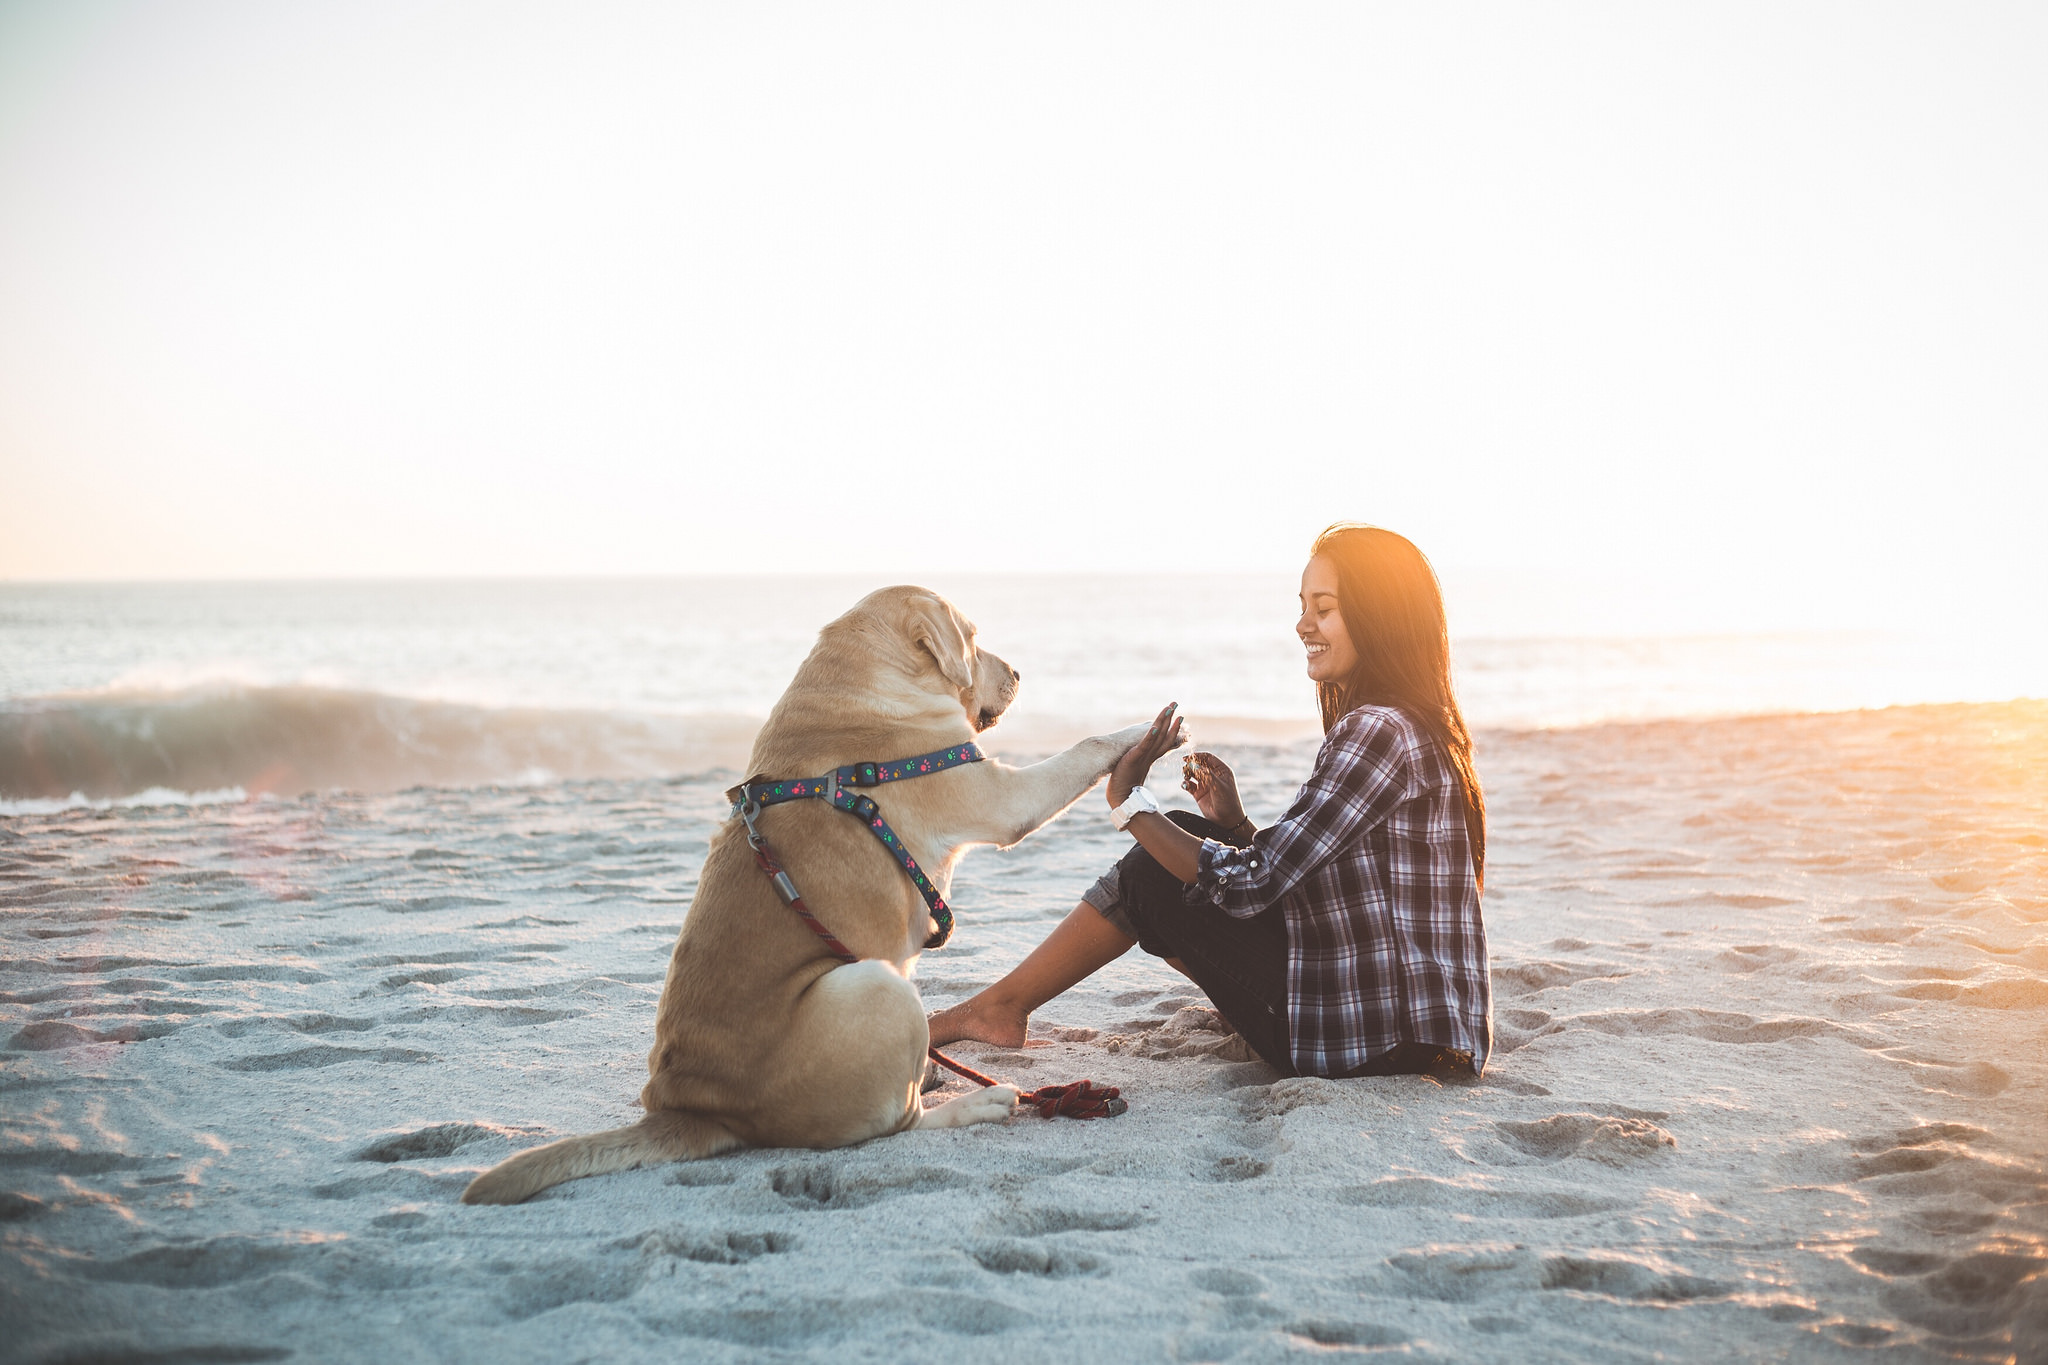

In [8]:
image

- Write the `question` you want to ask to the model about the image.

In [9]:
question = "how many dogs are in the picture?"

In [10]:
inputs = processor(image, question, return_tensors="pt")

In [11]:
out = model.generate(**inputs)

In [13]:
print(processor.decode(out[0], skip_special_tokens=True))

1


In [15]:
# 1. Define the text prompt you want to ask about the image.
question = "how many women are in the picture?"

# 2. Process the raw image and text into a mathematical format.
# return_tensors="pt" forces the output to be PyTorch tensors instead of standard Python lists.
inputs = processor(image, question, return_tensors="pt")

# 3. Feed the processed data into the model to generate an answer.
# The '**' operator unpacks the 'inputs' dictionary into separate keyword arguments.
out = model.generate(**inputs)

# 4. Translate the model's numerical output back into human-readable English.
# skip_special_tokens=True removes hidden formatting tags (like <pad> or </s>) from the printed text.
print(processor.decode(out[0], skip_special_tokens=True))

1


### Try it yourself!
- Try this model with your own images and questions!

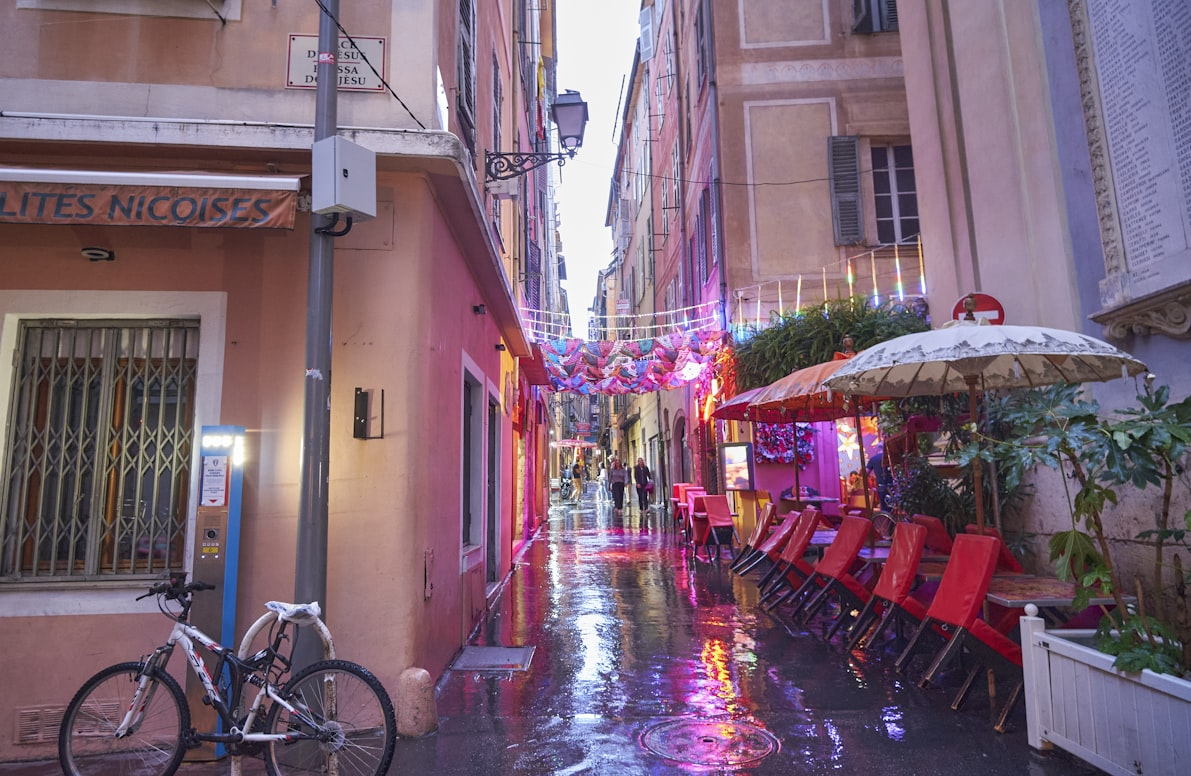

In [16]:
image_url="https://images.unsplash.com/photo-1664726517307-be19322a191b?q=80&w=1191&auto=format&fit=crop&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxwaG90by1wYWdlfHx8fGVufDB8fHx8fA%3D%3D"
response = requests.get(image_url)
image = Image.open(BytesIO(response.content))
image

In [17]:
question = "where is taken the picture?"
inputs = processor(image, question, return_tensors="pt")
out = model.generate(**inputs)
print(processor.decode(out[0], skip_special_tokens=True))

on street
